In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_dataset.csv")
print(df.head())

Matplotlib is building the font cache; this may take a moment.


  show_id            title     type  release_year        genre country  \
0   s0001  Netflix Title 1    Movie          2010  Documentary   India   
1   s0002  Netflix Title 2    Movie          2023        Drama     USA   
2   s0003  Netflix Title 3    Movie          2016  Documentary   Spain   
3   s0004  Netflix Title 4  TV Show          2010      Romance   Japan   
4   s0005  Netflix Title 5    Movie          2016      Romance   India   

   rating  duration_min  views_millions  
0     6.1            77           184.4  
1     5.4            89           126.8  
2     8.2           113            55.9  
3     5.7           114            85.7  
4     5.5           108            25.1  


Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


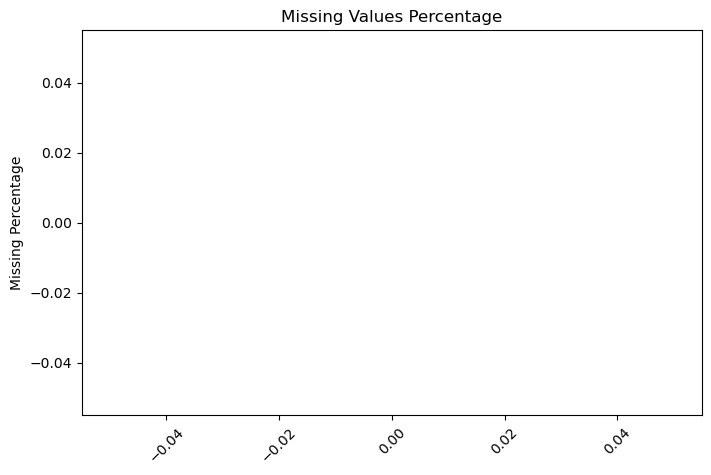

In [2]:
# Missing values count
missing = df.isnull().sum()

# Missing percentage
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

missing_df = missing_df[missing_df["Missing Values"] > 0]

print(missing_df)

# Visualization
plt.figure(figsize=(8,5))
plt.bar(missing_df.index, missing_df["Percentage"])
plt.xticks(rotation=45)
plt.ylabel("Missing Percentage")
plt.title("Missing Values Percentage")
plt.show()

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Check if the column exists
if "date_added" in df.columns:

    df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

    titles_per_year = df["date_added"].dt.year.value_counts().sort_index()

    print(titles_per_year)

    plt.figure(figsize=(10,5))
    plt.plot(titles_per_year.index, titles_per_year.values, marker='o')
    plt.xlabel("Year")
    plt.ylabel("Number of Titles")
    plt.title("Netflix Titles Added Each Year")
    plt.grid(True)
    plt.show()

else:
    print("Column 'date_added' not found.")
    print("Available columns are:")
    print(df.columns.tolist())

Column 'date_added' not found.
Available columns are:
['show_id', 'title', 'type', 'release_year', 'genre', 'country', 'rating', 'duration_min', 'views_millions']


Movie      56
TV Show    44
Name: type, dtype: int64
Movie      56.0
TV Show    44.0
Name: type, dtype: float64


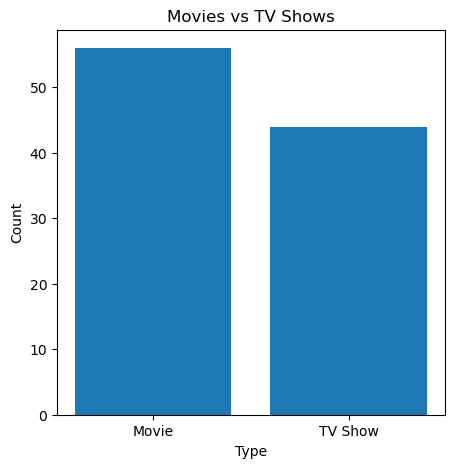

In [6]:
type_count = df["type"].value_counts()

print(type_count)

percentage = (type_count / len(df)) * 100
print(percentage)

plt.figure(figsize=(5,5))
plt.bar(type_count.index, type_count.values)
plt.xlabel("Type")
plt.ylabel("Count")
plt.title("Movies vs TV Shows")
plt.show()

USA            21
UK             18
Japan          16
India          12
Canada         12
Spain          11
South Korea    10
dtype: int64


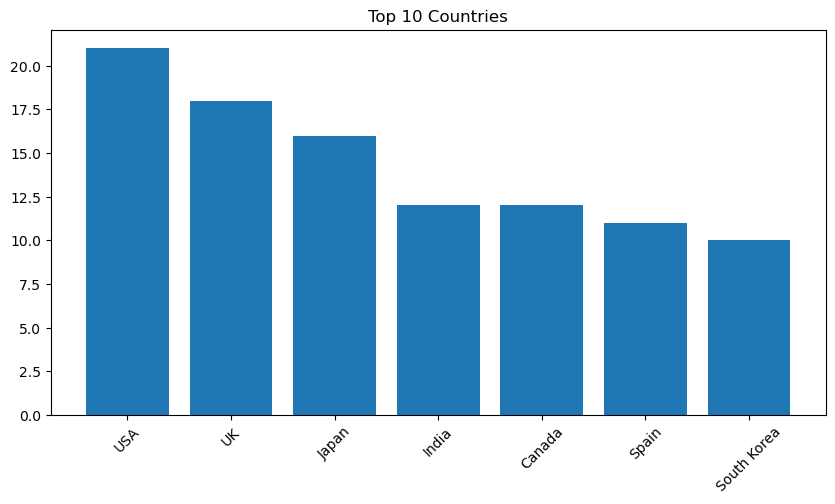

In [7]:
countries = df["country"].dropna().str.split(", ")

country_list = []

for i in countries:
    country_list.extend(i)

country_series = pd.Series(country_list)

top10 = country_series.value_counts().head(10)

print(top10)

plt.figure(figsize=(10,5))
plt.bar(top10.index, top10.values)
plt.xticks(rotation=45)
plt.title("Top 10 Countries")
plt.show()

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Check if 'listed_in' column exists
if 'listed_in' in df.columns:

    genres = df['listed_in'].fillna('').str.split(', ')

    genre_list = []

    for g in genres:
        genre_list.extend(g)

    # Remove empty values
    genre_list = [x for x in genre_list if x != '']

    genre_series = pd.Series(genre_list)

    top10_genres = genre_series.value_counts().head(10)

    print(top10_genres)

    plt.figure(figsize=(10,5))
    plt.barh(top10_genres.index, top10_genres.values)
    plt.xlabel("Count")
    plt.ylabel("Genres")
    plt.title("Top 10 Most Common Netflix Genres")
    plt.show()

else:
    print("Column 'listed_in' not found.")
    print("Available columns are:")
    print(df.columns.tolist())

Column 'listed_in' not found.
Available columns are:
['show_id', 'title', 'type', 'release_year', 'genre', 'country', 'rating', 'duration_min', 'views_millions']


Mean: 2017.25
Median: 2017.5
Standard Deviation: 4.493050188902857


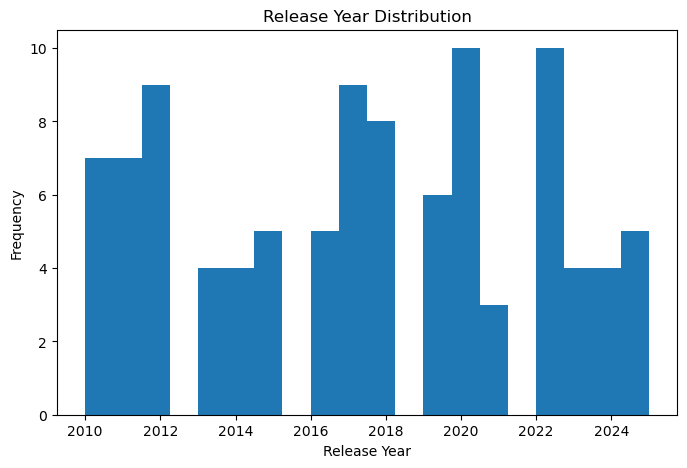

In [10]:
years = df["release_year"]

print("Mean:", np.mean(years))
print("Median:", np.median(years))
print("Standard Deviation:", np.std(years))

plt.figure(figsize=(8,5))
plt.hist(years, bins=20)
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.title("Release Year Distribution")
plt.show()

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Check if required columns exist
if 'type' in df.columns and 'duration' in df.columns:

    # Select only movies
    movies = df[df['type'] == 'Movie'].copy()

    # Extract only numbers from duration
    movies['duration'] = movies['duration'].str.extract('(\d+)')

    # Remove missing values
    movies = movies.dropna(subset=['duration'])

    # Convert to integer
    movies['duration'] = movies['duration'].astype(int)

    # Statistics
    print("Average Duration:", movies['duration'].mean())
    print("Shortest Movie:", movies['duration'].min())
    print("Longest Movie:", movies['duration'].max())

    # Histogram
    plt.figure(figsize=(8,5))
    plt.hist(movies['duration'], bins=20, edgecolor='black')
    plt.xlabel("Duration (Minutes)")
    plt.ylabel("Number of Movies")
    plt.title("Distribution of Movie Durations")
    plt.grid(True)
    plt.show()

else:
    print("Required columns ('type' or 'duration') are not found.")
    print("Available columns:")
    print(df.columns.tolist())

Required columns ('type' or 'duration') are not found.
Available columns:
['show_id', 'title', 'type', 'release_year', 'genre', 'country', 'rating', 'duration_min', 'views_millions']


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

if "date_added" in df.columns:

    df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
    df["month"] = df["date_added"].dt.month_name()

    month_order = ["January","February","March","April","May","June",
                   "July","August","September","October","November","December"]

    monthly = df["month"].value_counts().reindex(month_order, fill_value=0)

    print(monthly)

    plt.figure(figsize=(10,5))
    plt.bar(monthly.index, monthly.values)
    plt.xticks(rotation=45)
    plt.xlabel("Month")
    plt.ylabel("Number of Titles")
    plt.title("Monthly Netflix Additions")
    plt.show()

else:
    print("Error: 'date_added' column not found.")
    print(df.columns.tolist())

Error: 'date_added' column not found.
['show_id', 'title', 'type', 'release_year', 'genre', 'country', 'rating', 'duration_min', 'views_millions']


In [18]:
 import pandas as pd
import matplotlib.pyplot as plt

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

if "director" in df.columns:

    directors = df["director"].fillna("").str.split(", ")

    director_list = []

    for d in directors:
        director_list.extend(d)

    # Remove empty values
    director_list = [x for x in director_list if x != ""]

    top10_directors = pd.Series(director_list).value_counts().head(10)

    print(top10_directors)

    plt.figure(figsize=(10,5))
    plt.bar(top10_directors.index, top10_directors.values)
    plt.xticks(rotation=60)
    plt.xlabel("Director")
    plt.ylabel("Number of Titles")
    plt.title("Top 10 Directors on Netflix")
    plt.show()

else:
    print("Error: 'director' column not found.")
    print(df.columns.tolist())

Error: 'director' column not found.
['show_id', 'title', 'type', 'release_year', 'genre', 'country', 'rating', 'duration_min', 'views_millions']
